# 03 - The horizon, and what a job-level score looks like

`01` showed the model is variance-limited, with an effective sample size closer to
the ~10,265 training **jobs** than to the 915,508 windows. `02` showed that nine
job-context columns more than double what 56 telemetry aggregates achieve.

Two things are still fixed by convention rather than by evidence, and both are free
to change:

**The horizon.** A window is positive when it falls within 2 hours of a failing
job's end. That 2 h is inherited, not justified. A shorter horizon puts the positive
label where a precursor would actually be, and lowers the positive rate - so lift can
move even if average precision does not.

**The unit of evaluation.** Every number so far is per *window*, but nobody operates
per window. What matters is whether a **job** gets flagged before it dies. Scoring at
job level is not a trick to make the number look better; it is the number that
corresponds to the decision anyone would actually make.

## Pre-registration

**H1.** Shortening the horizon raises **lift** (positives concentrate near the
failure, and the baseline falls), while absolute AP may fall.

**H2.** Job-level AP will be much higher than window-level AP, because a job gets
many chances to be flagged and only needs one.

**H3.** The context/telemetry ordering from `02` will survive both changes - context
will still beat telemetry at every horizon. If it does not, the `02` result depends
on the 2 h convention and must be reported as such.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, n_jobs=-1, random_state=0)
WINDOW, SNAP_S = 40, 30.0
HORIZONS = [0.25, 0.5, 1.0, 2.0, 4.0]
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print("setup ok")

setup ok


## Step 1 - Re-labelling in closed form

A window holds 40 snapshots at a 30 s cadence. `ttf_end` is the time from the
window's **last** snapshot to the job's end, so snapshot *i* counting backwards sits
at `ttf_end + i*30` seconds from the end. The window is positive under horizon `H`
when at least 20 of its 40 snapshots fall inside `H`, i.e.

```
ttf_end + 19*30 <= H*3600      ->      ttf_end <= H*3600 - 570
```

So any horizon can be re-labelled arithmetically, with no rebuild of the windows.
The cell below **verifies** this reproduces the stored labels at `H = 2` before
using it anywhere else.

In [2]:
w = pd.read_parquet(EDA / "windows.parquet")
jobs = pd.read_parquet(EDA / "jobs.parquet",
                       columns=["slurm_id", "start_date", "numcores"])
w = w.merge(jobs, on="slurm_id", how="left")

TELEMETRY = [c for c in w.columns if "__" in c]
elapsed_s = (w.t_end - w.start_date).dt.total_seconds().to_numpy()
w["elapsed_h"]           = elapsed_s / 3600.0
w["sec_into_hour"]       = elapsed_s % 3600.0
w["sec_to_next_hour"]    = 3600.0 - (elapsed_s % 3600.0)
w["elapsed_hours_floor"] = np.floor(elapsed_s / 3600.0)
w["queue_code"]          = w.nodetypes.astype(str).astype("category").cat.codes
w["hour_of_day"]         = w.t_end.dt.hour
w["dow"]                 = w.t_end.dt.dayofweek
CONTEXT = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
           "queue_code", "numnodes", "numcores", "hour_of_day", "dow"]
SETS = {"T  telemetry": TELEMETRY, "C  context": CONTEXT,
        "T+C  both": TELEMETRY + CONTEXT}

is_fail = w.state.astype(str).isin(FAILURE_STATES).to_numpy()
ttf     = w.ttf_end.to_numpy()

def relabel(H):
    # majority vote needs >= WINDOW/2 positive snapshots; snapshot i (counting back
    # from the last) sits at ttf_end + i*30, so the binding one is i = WINDOW/2 - 1.
    return (is_fail & (ttf >= 0)
            & (ttf <= H * 3600 - (WINDOW // 2 - 1) * SNAP_S)).astype(np.int8)

check = relabel(2.0)
agree = (check == w.y.to_numpy()).mean()
print(f"closed-form re-labelling reproduces the stored H=2 labels: {100*agree:.4f} % of rows")
print(f"stored positives {int(w.y.sum()):,}   recomputed {int(check.sum()):,}")
assert agree == 1.0, "closed-form re-labelling does not match the stored labels"

closed-form re-labelling reproduces the stored H=2 labels: 100.0000 % of rows
stored positives 35,665   recomputed 35,665


## Step 2 - The horizon sweep

Each horizon is a different prediction task, with its own positive rate and therefore
its own baseline. Absolute AP across horizons is **not** comparable; lift is.

In [3]:
tr_mask = (w.split == "train").to_numpy()
te_mask = ~tr_mask
te_df   = w[te_mask]

rows = []
for H in HORIZONS:
    yH = relabel(H)
    ytr, yte = yH[tr_mask], yH[te_mask]
    if yte.sum() < 50:
        print(f"H={H}: too few test positives ({yte.sum()}), skipped"); continue
    for name, cols in SETS.items():
        m  = lgb.LGBMClassifier(**PARAMS).fit(w.loc[tr_mask, cols], ytr)
        sc = m.predict_proba(w.loc[te_mask, cols])[:, 1]
        ap, base = average_precision_score(yte, sc), yte.mean()
        rows.append(dict(horizon_h=H, features=name, test_pos=int(yte.sum()),
                         base=base, ap=ap, lift=ap / base))
    print(f"H={H:5.2f} h  positives train {int(ytr.sum()):>6,} / test {int(yte.sum()):>5,} "
          f" base {100*yte.mean():5.2f} %   [{time.time()-t0:.0f}s]")

S = pd.DataFrame(rows)
S.to_csv(DATA / "horizon_sweep.csv", index=False)
print()
print("LIFT by horizon")
print(S.pivot(index="horizon_h", columns="features", values="lift").round(2).to_string())
print()
print("average precision by horizon")
print(S.pivot(index="horizon_h", columns="features", values="ap").round(4).to_string())

H= 0.25 h  positives train  2,232 / test   499  base  0.35 %   [32s]


H= 0.50 h  positives train  6,941 / test 1,498  base  1.05 %   [62s]


H= 1.00 h  positives train 15,526 / test 3,178  base  2.23 %   [93s]


H= 2.00 h  positives train 29,839 / test 5,826  base  4.09 %   [122s]


H= 4.00 h  positives train 52,205 / test 9,815  base  6.90 %   [152s]

LIFT by horizon
features   C  context  T  telemetry  T+C  both
horizon_h                                     
0.25            11.12          1.58       5.21
0.50             8.93          1.58       8.44
1.00             7.08          1.80       5.00
2.00             4.65          1.95       4.74
4.00             3.22          2.17       3.39

average precision by horizon
features   C  context  T  telemetry  T+C  both
horizon_h                                     
0.25           0.0390        0.0055     0.0183
0.50           0.0940        0.0166     0.0889
1.00           0.1582        0.0402     0.1116
2.00           0.1903        0.0797     0.1941
4.00           0.2220        0.1498     0.2340


In [4]:
piv = S.pivot(index="horizon_h", columns="features", values="lift")
best_h = piv["T+C  both"].idxmax()
facts["best_horizon_h"] = float(best_h)
facts["lift_by_horizon"] = {str(h): float(v) for h, v in piv["T+C  both"].items()}
facts["telemetry_lift_by_horizon"] = {str(h): float(v) for h, v in piv["T  telemetry"].items()}

h1 = piv["T+C  both"].iloc[0] > piv["T+C  both"].loc[2.0]
h3 = bool((piv["C  context"] > piv["T  telemetry"]).all())
print(f"H1  shorter horizon raises lift : {'CONFIRMED' if h1 else 'REJECTED'}")
print(f"    best horizon for T+C        : {best_h} h  (lift {piv['T+C  both'].max():.2f}x)")
print(f"H3  context beats telemetry at every horizon : {'CONFIRMED' if h3 else 'REJECTED'}")

H1  shorter horizon raises lift : CONFIRMED
    best horizon for T+C        : 0.5 h  (lift 8.44x)
H3  context beats telemetry at every horizon : CONFIRMED


## Step 3 - Job-level evaluation

Back to the 2 h horizon, and now scoring **jobs** rather than windows. A job's score
is the maximum score over its windows - the natural rule, since one alert is enough.
A job is positive when it ends in a failure state.

Only jobs that produced at least one complete window can be scored at all. The jobs
that never produce one are not "missed by the model"; they are outside its reach, and
`eda/03` already quantified that as the coverage ceiling.

In [5]:
y2 = relabel(2.0)
job_rows = []
for name, cols in SETS.items():
    m  = lgb.LGBMClassifier(**PARAMS).fit(w.loc[tr_mask, cols], y2[tr_mask])
    sc = m.predict_proba(w.loc[te_mask, cols])[:, 1]
    d  = pd.DataFrame({"slurm_id": te_df.slurm_id.to_numpy(),
                       "state":    te_df.state.astype(str).to_numpy(),
                       "score":    sc,
                       "ttf_end":  te_df.ttf_end.to_numpy()})
    g = d.groupby("slurm_id").agg(score=("score", "max"),
                                  state=("state", "first")).reset_index()
    yj = g.state.isin(FAILURE_STATES).astype(int).to_numpy()
    ap, base = average_precision_score(yj, g.score.to_numpy()), yj.mean()
    job_rows.append(dict(features=name, jobs=len(g), failing=int(yj.sum()),
                         base=base, job_ap=ap, job_lift=ap / base))
    print(f"{name:14s} {len(g):,} scorable test jobs, {int(yj.sum()):,} failing "
          f"({100*base:.1f} %)   job AP {ap:.4f} = {ap/base:.2f}x   [{time.time()-t0:.0f}s]")

J = pd.DataFrame(job_rows)
J.to_csv(DATA / "job_level.csv", index=False)
facts["job_level"] = {r.features: float(r.job_ap) for _, r in J.iterrows()}
facts["job_level_lift"] = {r.features: float(r.job_lift) for _, r in J.iterrows()}

win_ap = S[(S.horizon_h == 2.0)].set_index("features").ap
print()
print("window level vs job level, same models, same horizon:")
for n in SETS:
    jl = J[J.features == n].job_ap.iloc[0]
    print(f"  {n:14s} window AP {win_ap[n]:.4f}   ->   job AP {jl:.4f}")

T  telemetry   2,694 scorable test jobs, 378 failing (14.0 %)   job AP 0.3938 = 2.81x   [163s]


C  context     2,694 scorable test jobs, 378 failing (14.0 %)   job AP 0.4009 = 2.86x   [168s]


T+C  both      2,694 scorable test jobs, 378 failing (14.0 %)   job AP 0.4725 = 3.37x   [181s]

window level vs job level, same models, same horizon:
  T  telemetry   window AP 0.0797   ->   job AP 0.3938
  C  context     window AP 0.1903   ->   job AP 0.4009
  T+C  both      window AP 0.1941   ->   job AP 0.4725


## Step 4 - The figure

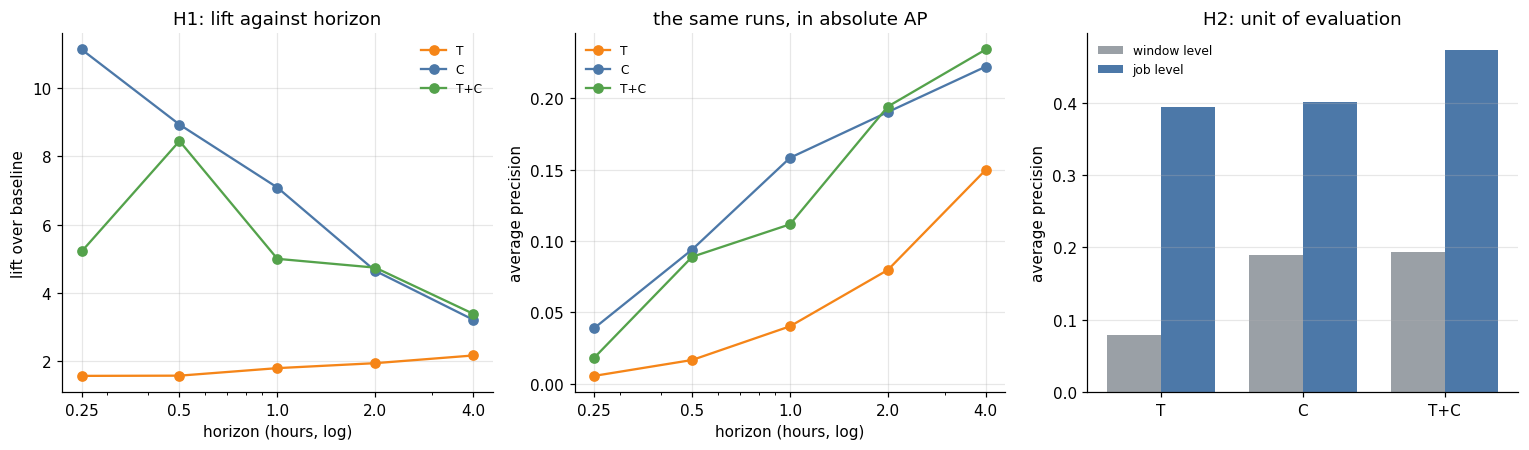

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

for col, c in zip(["T  telemetry", "C  context", "T+C  both"],
                  ["#f58518", "#4c78a8", "#54a24b"]):
    ax[0].plot(piv.index, piv[col], "o-", color=c, label=col.split()[0])
ax[0].set(xscale="log", xlabel="horizon (hours, log)", ylabel="lift over baseline",
          title="H1: lift against horizon")
ax[0].set_xticks(HORIZONS, [str(h) for h in HORIZONS])
ax[0].legend(frameon=False, fontsize=8)

pap = S.pivot(index="horizon_h", columns="features", values="ap")
for col, c in zip(["T  telemetry", "C  context", "T+C  both"],
                  ["#f58518", "#4c78a8", "#54a24b"]):
    ax[1].plot(pap.index, pap[col], "o-", color=c, label=col.split()[0])
ax[1].set(xscale="log", xlabel="horizon (hours, log)", ylabel="average precision",
          title="the same runs, in absolute AP")
ax[1].set_xticks(HORIZONS, [str(h) for h in HORIZONS])
ax[1].legend(frameon=False, fontsize=8)

x = np.arange(len(J)); wd = 0.38
ax[2].bar(x - wd/2, win_ap.reindex(J.features).to_numpy(), wd,
          label="window level", color="#9aa0a6")
ax[2].bar(x + wd/2, J.job_ap, wd, label="job level", color="#4c78a8")
ax[2].set_xticks(x, [n.split()[0] for n in J.features])
ax[2].set(ylabel="average precision", title="H2: unit of evaluation")
ax[2].legend(frameon=False, fontsize=8); ax[2].grid(axis="x", visible=False)

plt.tight_layout(); save(fig, "03_horizon_joblevel.png"); plt.show()

## Step 5 - Verdict

In [7]:
json.dump(facts, open(DATA / "facts_horizon.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k}: {v}")
print(f"\n[{time.time()-t0:.0f}s total]")

best_horizon_h: 0.5
lift_by_horizon: {'0.25': 5.213705989680123, '0.5': 8.44451125542085, '1.0': 4.998999858537226, '2.0': 4.7414638008724, '4.0': 3.3933324189253633}
telemetry_lift_by_horizon: {'0.25': 1.5754481639506184, '0.5': 1.5816526570055678, '1.0': 1.8017926379215259, '2.0': 1.947097916760991, '4.0': 2.1716930252293154}
job_level: {'T  telemetry': 0.39376837508820217, 'C  context': 0.40090916331548077, 'T+C  both': 0.4724561665376712}
job_level_lift: {'T  telemetry': 2.806380958961949, 'C  context': 2.8572732433119183, 'T+C  both': 3.3671875996097516}

[182s total]


### How to read the job-level number

The job-level figure is the honest operational one, but it must be quoted with the
denominator attached. It covers only the test jobs that produced at least one
complete 20-minute window. `eda/` measured that population: two thirds of failing
jobs never last long enough to produce one, and the median FAILED job runs for a
single minute.

So a good job-level score does **not** mean most failures are caught. It means most
failures *that are observable at all* are ranked ahead of healthy jobs. Both halves
have to appear in the same sentence, or the number misleads.